# 开始使用Jupyter notebook写博客


2020-03-20 10:41:38 

几天前得知自从jupyter notebook在5.0以上的版本，就可以随意的插入图片了！可以拖拽的方式，也可以直接复制粘贴的方式。并且这个图片是以attachment的方式存储的，不需要再设置存储路径之类的事情。还有比这更方便的事情吗！

但是我使用pip install的方式update jupyter notebook却并未发现这一神奇功能。这太反常了。昨天晚上，我检索了半天。最后决定尝试使用conda install的方式安装。结果把anaconda搞[崩溃了！](https://www.douban.com/people/frankwang/status/2875321344/)

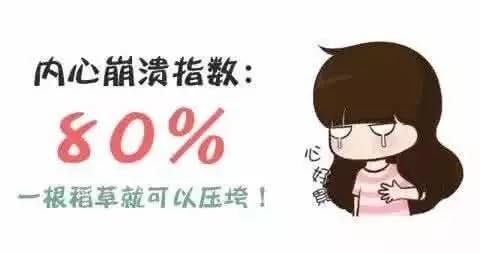

算了！删除重装！反正也没什么太多的个性化的软件。发现R的kernel居然还在！Stata的需要重新安装。

```
pip install stata_kernel
python -m stata_kernel.install
```

另外，重新安装[jupyter_contrib_nbextensions](https://github.com/ipython-contrib/jupyter_contrib_nbextensions
)和 [RISE](https://github.com/damianavila/RISE)。

一切搞定！果然可以插图了。感觉一切都值得！看看我的大魔法！

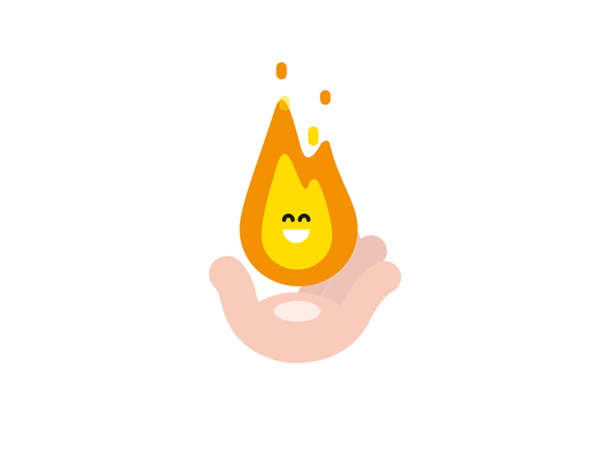





## Python代码是必需的！

In [24]:
from __future__ import print_function, division
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

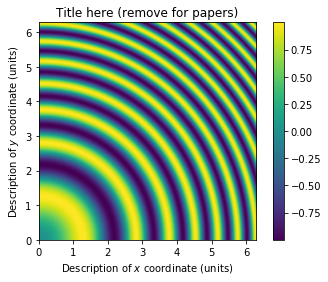

In [2]:
# Silly example data
x_min, x_max, y_min, y_max = 0.0, 2*np.pi, 0.0, 2*np.pi
f = [[np.sin(x**2 + y**2) for x in np.linspace(x_min, x_max, num=200)]
     for y in np.linspace(y_min, y_max, num=200)]

# Make the plot
plt.figure()
plt.imshow(f, interpolation="bicubic", origin="lower",
           extent=[x_min, x_max, y_min, y_max])
plt.colorbar()
plt.title(r"Title here (remove for papers)")
plt.xlabel(r"Description of $x$ coordinate (units)")
plt.ylabel(r"Description of $y$ coordinate (units)")
plt.show()

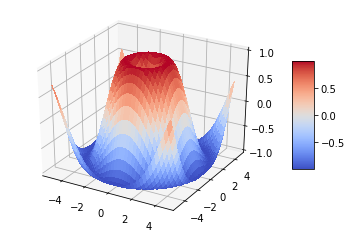

In [3]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Silly example data
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# Make the plot
fig = plt.figure()
ax = fig.gca(projection="3d")
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-1.01, 1.01)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

## 还有数学公式

\begin{equation}
  e^x = \sum_{j=0}^{\infty} \frac{1}{j!} x^j
\end{equation}

## 如何在线浏览呢？

方法1. 使用nbviewer

https://nbviewer.jupyter.org/github/chengjun/notebook/tree/master/


方法2. 批量生成html文件

https://chengjunwang.com/notebook/20200320-hello-notebook.html

我决定使用方法1 nbviewer的方式，需要的时候再批量生成html文件。

上传到github还是使用github desktop的傻瓜方式，简单明了！

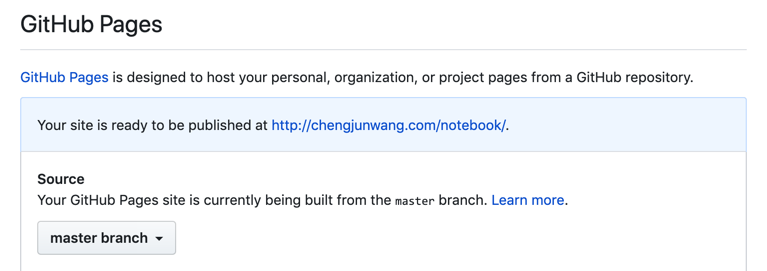

另外，发现可以在github的setting里设置github pages的source为master branch!如上图。

# 自动生成网页同时上传到Github

In [25]:
!jupyter nbconvert --to html *.ipynb
!sh deploy.sh

[NbConvertApp] Converting notebook 20200320-hello-notebook.ipynb to html
[NbConvertApp] Writing 2373263 bytes to 20200320-hello-notebook.html
-e Deploying updates to GitHub...
[master 324e125] rebuilding site
 2 files changed, 28 insertions(+), 28 deletions(-)
Counting objects: 4, done.
Delta compression using up to 8 threads.
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 958 bytes | 958.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To github.com:chengjun/notebook.git
   16c5776..324e125  master -> master


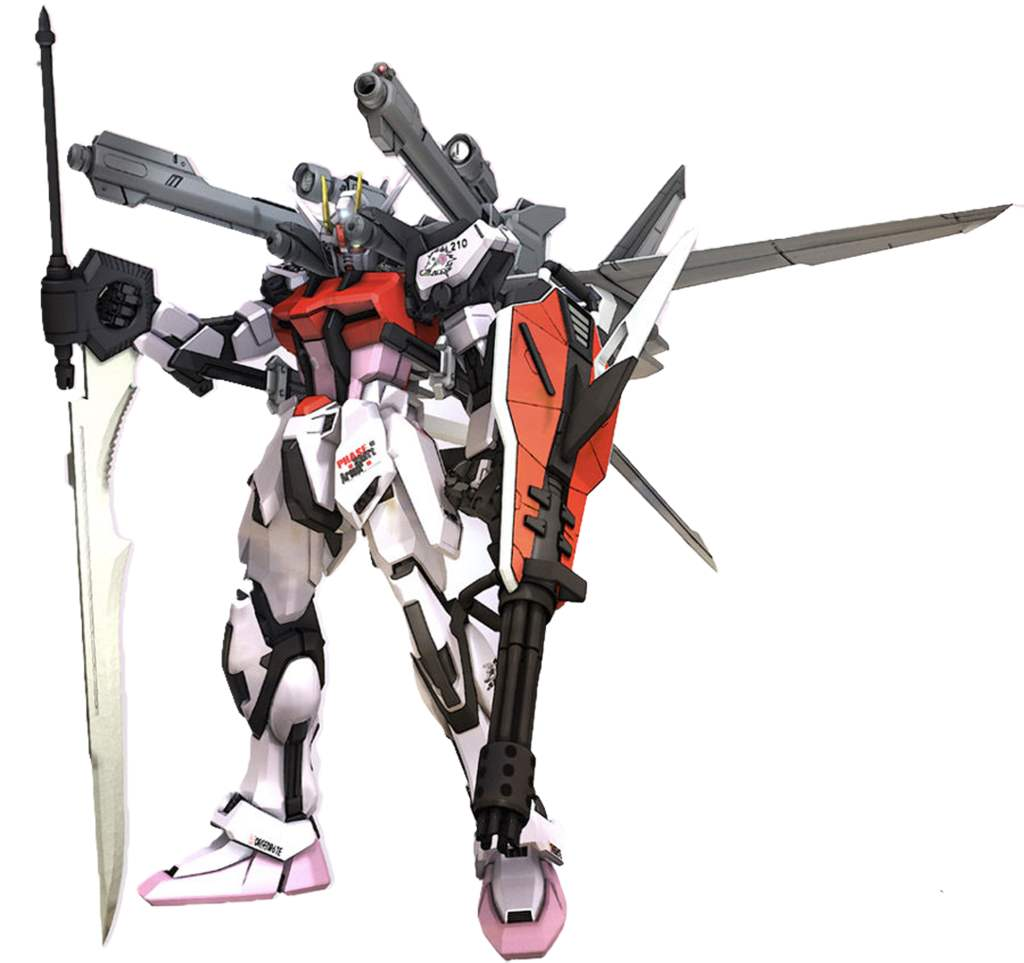

### 自动生成网页

```
!jupyter nbconvert --to html *.ipynb
```

In [22]:
!jupyter nbconvert --to html *.ipynb

[NbConvertApp] Converting notebook 20200320-hello-notebook.ipynb to html
[NbConvertApp] Writing 2373259 bytes to 20200320-hello-notebook.html


### 上传到github

deploy.sh文件内容如下

```bash
#!/bin/bash

echo -e "\033[0;32mDeploying updates to GitHub...\033[0m"

#git config 'lfs.https://github.com/chengjun/notebook.git/info/lfs.locksverify' false

git pull first
git pull origin master
ssh-add ~/.ssh/id_rsa
git remote set-url origin git@github.com:chengjun/notebook.git

# Add changes to git.
git add -A

# Commit changes.
msg="rebuilding site"
if [ $# -eq 1 ]
  then msg="$1"
fi
git commit -m "$msg"

# Push source and build repos.
git push origin master
```

### 运行shell 命令

```
!sh deploy.sh
```

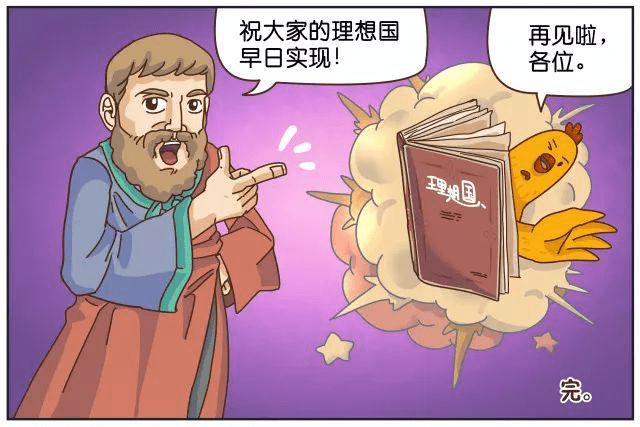